## 2n-DC Analysis

In [58]:
# import
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import MDAnalysis as mda
import xarray as arr
import mdtraj as md
import scipy
from MDAnalysis.analysis import distances

In [59]:
# paths to simulations
path1 = "/data/geissler/simulations/rec_lig/2n-dc/normCA/1rep/"  # path to replica1
path2 = "/data/geissler/simulations/rec_lig/2n-dc/normCA/2rep/"  # path to replica2
path3 = "/data/geissler/simulations/rec_lig/2n-dc/normCA/3rep/"  # path to replica3
path_combined = "/data/geissler/simulations/rec_lig/2n-dc/normCA/combined/"  # path to folder with concatenated version of all 3 replicas
path_stats = "/data/geissler/simulations/rec_lig/2n-dc/normCA/combined/stats/"  # path to save results

## RMSD Calcium and Ligand to pocket

### Cal to pocket

RMSD was calculated with gromacs using the protein backbone as the group for least squares fit and the Calcium atom for the RMSD calculation. The trajectory was centered on the pocket atoms, otherwise the calcium atoms jumps in and out of the box.

In [69]:
# load data
rmsd_cal_center = np.loadtxt(f"{path_stats}cal_center_rmsd.xvg",
                     comments =['#','@'])
rmsd_cal_center[:, 0] = np.arange(0, len(rmsd_cal_center))
rmsd_lig = np.loadtxt(f"{path_stats}rmsd_lig.xvg",
                     comments =['#','@'])
rmsd_lig[:, 0] = np.arange(0, len(rmsd_cal_center))

In [70]:
# smooth RMSD over 20 frames
def movingaverage(values, window):
    weights = np.repeat(1.0, window)/window
    sma = np.convolve(values, weights, 'valid')
    return sma
av = 20

In [71]:
rmean_cal = movingaverage(rmsd_cal_center[:,1], av)
rmean_lig = movingaverage(rmsd_lig[:,1], av)

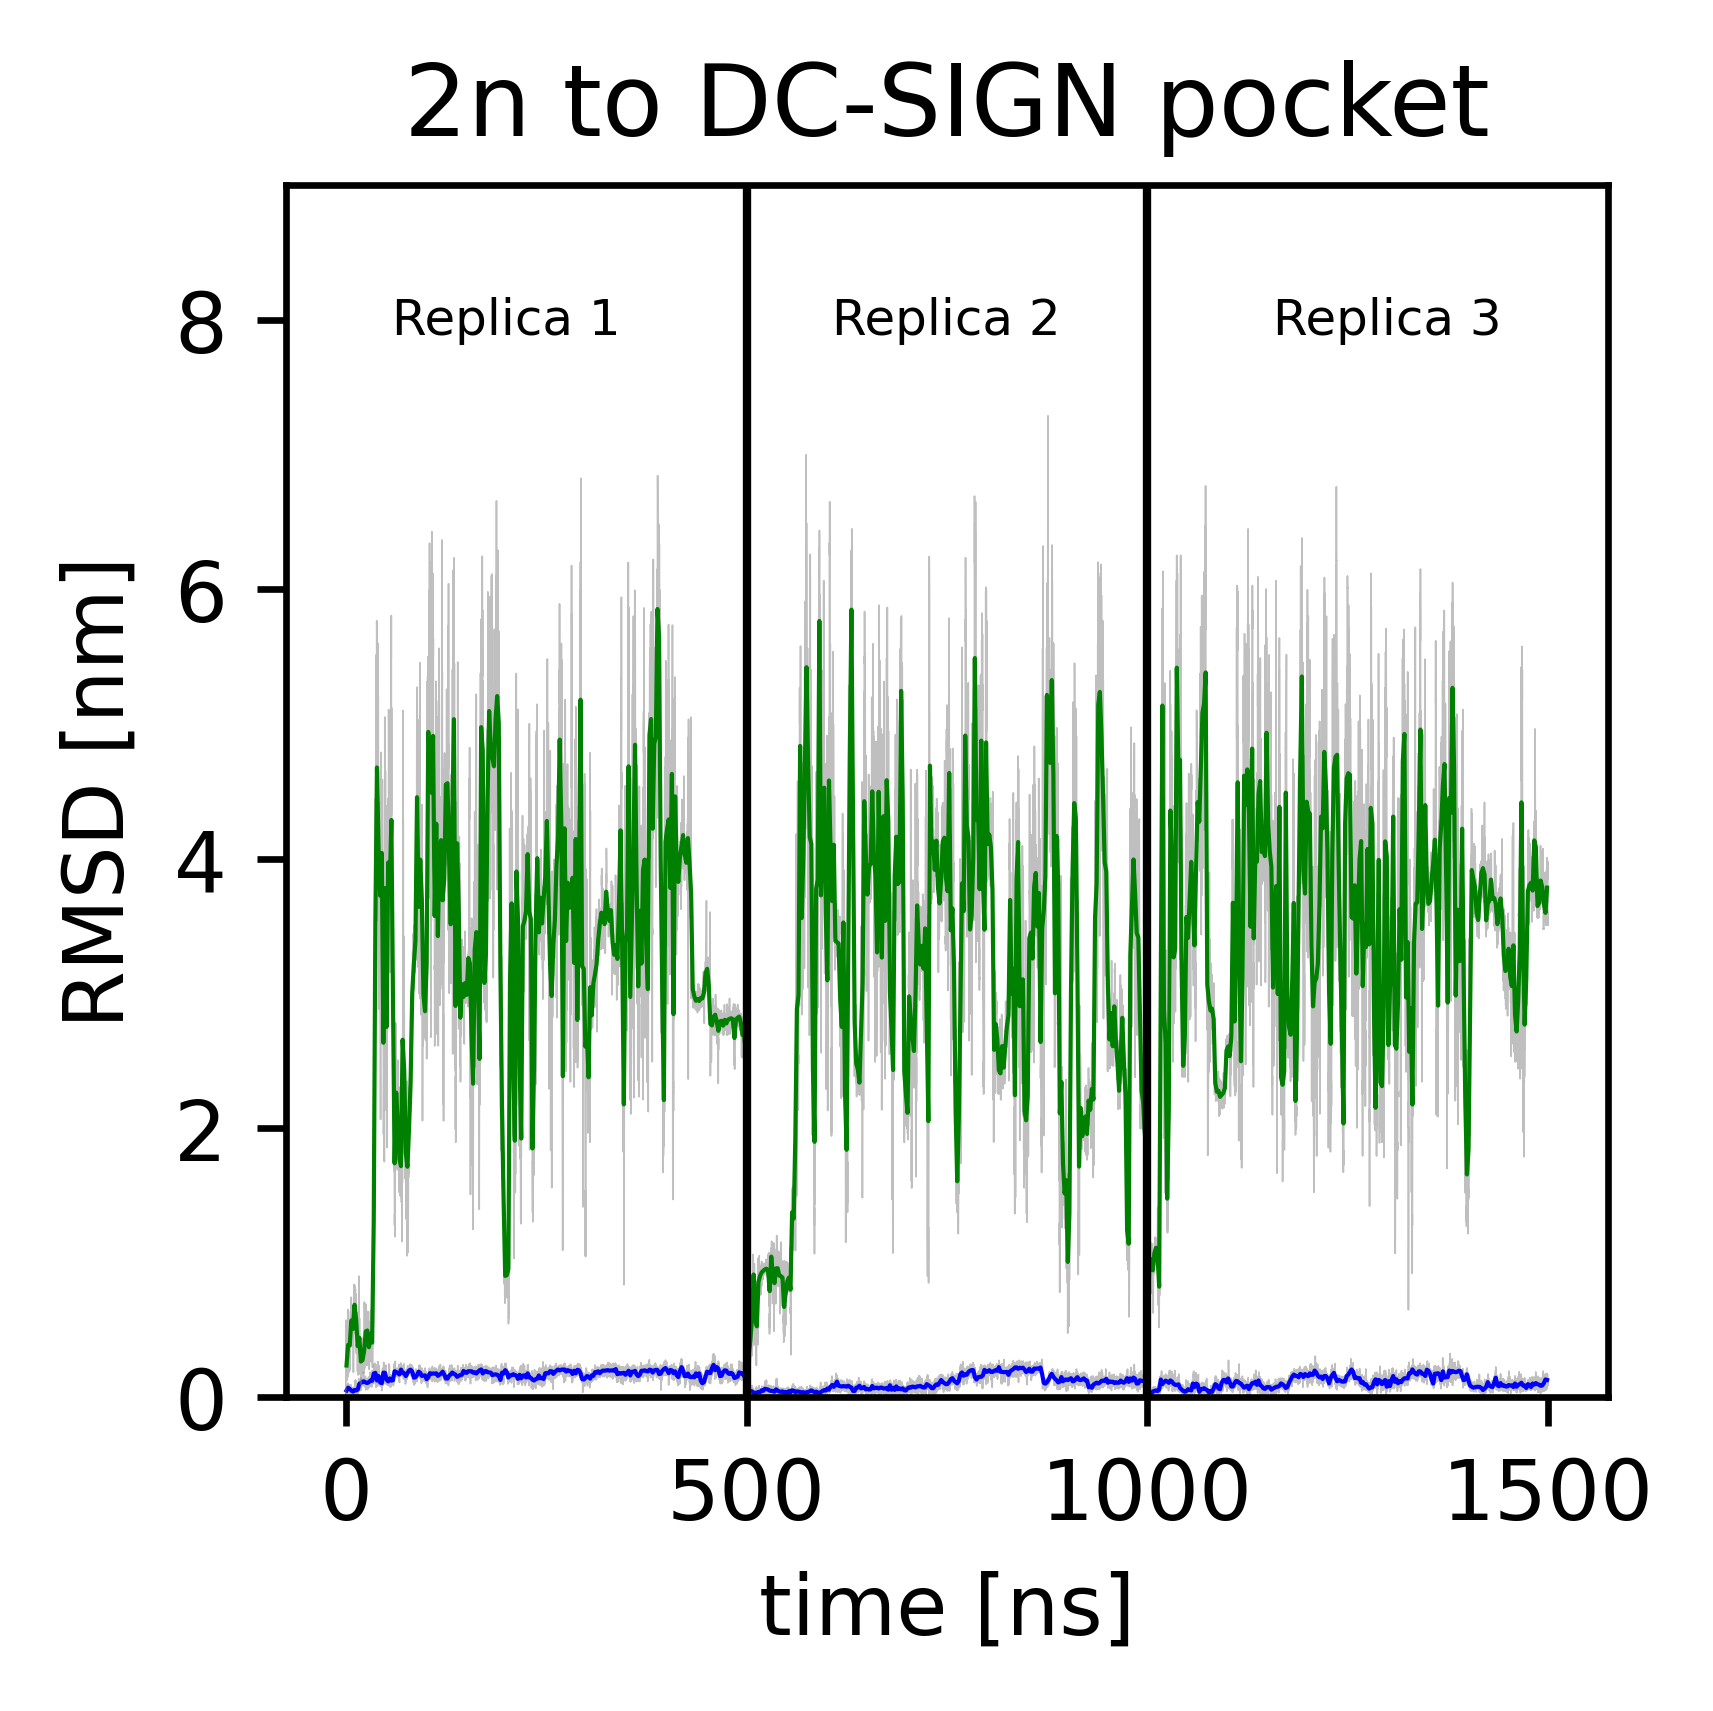

In [74]:
# plot RMSD
cm = 1/2.54
fig, ax = plt.subplots(figsize=(7.5*cm, 7.5*cm), dpi=600)

ax.plot(rmsd_cal_center.T[1], linewidth=0.2, c='grey', alpha=0.5)  # RMSD Cal
ax.plot(rmsd_cal_center[int(av/2-1):-int(av/2),0][::av]/1, rmean_cal[::av], linewidth=0.5, c='#0000FF') # smoothed RMSD Cal
ax.plot(rmsd_lig.T[1], linewidth=0.2, c='grey', alpha=0.5)  # RMSD lig
ax.plot(rmsd_lig[int(av/2-1):-int(av/2),0][::av]/1, rmean_lig[::av], linewidth=0.5, c='green') # smoothed RMSD lig
plt.axvline(5000, color='#000000', linewidth=1)  # borders between replica
plt.axvline(10000, color='#000000', linewidth=1)

plt.text(2000, 8, "Replica 1", size=6, rotation=0.,  # labels
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(7500, 8, "Replica 2", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(13000, 8, "Replica 3", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))

ax.set_ylim(0,9)
# ax.set_xlim(0,15010)
plt.xticks([0, 5000, 10000, 15000,], ['0', '500', '1000', '1500',], fontsize=10)
plt.title('2n to DC-SIGN pocket')
ax.set_xlabel('time [ns]')
ax.set_ylabel('RMSD [nm]')
plt.tight_layout()
plt.savefig("/data/geissler/analysis/RMSD/cal_lig/2n-dc.png")

## different binding states

Here I define the different binding conformations ("binding states") by distances of different mannose Hydroxy-groups to different amino acids in the binding pocket of the receptor: 
<br> 
(the different HO-groups are hightlighted in Fig.5 of the paper)
- the "crystal state" is defined by HO4 being close to Glu347, HO3 being close to Glu354, HO6 being far away from Glu358 and HO2 being far away from Glu347
- "state A" is defined by HO2 being close to Glu347, HO4 being far from Glu347, HO6 being far from Glu358 and HO2 being far from Glu354
- "state B" is defined by HO2 being close to Glu354, HO4 being far from Glu347, HO6 being far from Glu358 and HO2 being far from Glu347
- "state C" is defined by HO6 being close to Glu358, HO3 being close to Glu354 and HO2 being far from Glu347 

In [13]:
# for the calculations I concatenated all frames of ligand being bound to the pocket
traj = mda.Universe(path_combined+'md_500ns.pdb',
                   path_combined+'combined_bound.xtc')

As I define the binding states by distances, I calculate the different distances between HO atoms and the respective amino acids

In [33]:
# this calculates the distance between the two defined atoms below for each frame of the simulation and appends them to a list
# distance 1: HO6 to Glutamic Acid 358
man = traj.select_atoms('resname LIG and name H15')  # !2n ligand atoms have different names: H15 = HO6
prot = traj.select_atoms('protein and resid 358 and name CD') 

distance1 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance1.append(dist_arr/10)  # convert from Angstr. to nm

In [35]:
# distance 2: HO2 to Glutamic Acid 347
man = traj.select_atoms('resname LIG and name H10')  # !2n ligand atoms have different names: H10 = HO2
prot = traj.select_atoms('protein and resid 347 and name CD')

distance2 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance2.append(dist_arr/10)  # convert from Angstr. to nm

In [36]:
# distance 3: HO3 to Glutamic Acid 354
man = traj.select_atoms('resname LIG and name H14')  # !2n ligand atoms have different names: H14 = HO3
prot = traj.select_atoms('protein and resid 354 and name CD')

distance3 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance3.append(dist_arr/10)  # convert from Angstr. to nm

In [37]:
# distance 4: HO4 to Glutamic Acid 347 
man = traj.select_atoms('resname LIG and name H13')  # !2n ligand atoms have different names: H13 = HO4
prot = traj.select_atoms('protein and resid 347 and name CD')

distance4 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance4.append(dist_arr/10)  # convert from Angstr. to nm

In [38]:
# distance 5: HO2 to Glutamic Acid 354
man = traj.select_atoms('resname LIG and name H10')  # !2n ligand atoms have different names: H10 = HO2  
prot = traj.select_atoms('protein and resid 354 and name CD')

distance5 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance5.append(dist_arr/10)  # convert from Angstr. to nm

In [39]:
# now I put them into 1 array
all_distances=np.column_stack((distance1,distance2,distance3,distance4,distance5))
# and make it flat
distances_flat=all_distances[:,:,0]
np.save(f"{path_stats}distances_flat.npy", distances_flat)

Now I sort the frames into their respective state. I defined the cutoff between close and far at 3.5 Ångström which roughliy corresponds to the length of a hydrogen bond.

In [41]:
# crystal state: HO4 close to Glu725, HO3 close to Glu733, HO6 far away from Glu737 and HO2 far away from Glu725
crystal = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][3] <= 0.35 and distances_flat[i][2] <= 0.35 and distances_flat[i][0] > 0.35 and distances_flat[i][1] > 0.35:
        crystal.append(i)
print(len(crystal))  # print how many frames correspond to the crystal state

324


In [42]:
# state A: HO2 close to Glu725, HO4 far from Glu725, HO6 far from Glu737 and HO2 far from Glu733
stateA = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][1] <= 0.35 and distances_flat[i][3] > 0.35 and  distances_flat[i][0] > 0.35 and distances_flat[i][4] > 0.35:
        stateA.append(i)
print(len(stateA))

369


In [43]:
# state B: HO2 close to Glu733, HO4 far from Glu725, HO6 far from Glu737 and HO2 far from Glu725
stateB = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][4] <= 0.35 and distances_flat[i][3] > 0.35 and distances_flat[i][0] > 0.35 and distances_flat[i][1] > 0.35:
        stateB.append(i)
print(len(stateB))

124


In [44]:
# state C: HO6 close to Glu737, HO3 close to Glu733 and HO2 far from Glu725
stateC = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][0] <= 0.35 and distances_flat[i][2] <= 0.35 and distances_flat[i][1] > 0.35:
        stateC.append(i)
print(len(stateC))

0


In [45]:
# this is how I find out how many frames do not fall into any defined state ("others")
len(distances_flat)-len(crystal)-len(stateA)-len(stateB)-len(stateC)

276

## get frames of specific states to make a trajectory

For mmPBSA calculation for the specific states and for producing state contact maps, I will bin the frames of the same state together into one state specific trajectory. 
<br>
However I will only do that if I get more than 100 frames for the state.
<br>
By multiplying the frame numbers with 100 ps and considering the order of replicas, I can use the output below directly as input for the 'states_trajectory.sh' bash script.

This is what the combined bound traj is made of:

- 1rep bound: 341 frames, 34 ns, 34100 ps
- 2rep bound: 601 frames, 60 ns, 60100 ps
- 3rep bound: 151 frames, 15 ns, 15100 ps

  1093 frames in total -> 109300 ps

### crystal state

In [46]:
ps = 100
crystal_ps= [x*ps for x in crystal] 
print(*crystal_ps[:300])

0 100 200 300 400 500 700 800 900 1000 1100 1500 1700 1900 2000 2100 2200 2300 2400 2600 2700 3000 3100 3400 3700 3800 3900 4200 4400 4500 4600 4700 4800 4900 5000 5100 5200 5300 5400 5500 5600 5700 5800 5900 6000 6100 6200 6300 6400 6500 6800 6900 7000 7100 7400 11100 11200 11300 11400 11500 11600 11700 12200 12300 12400 12500 13100 13200 13500 13700 13900 14700 15000 15200 15300 15400 15600 15900 16200 17200 17300 17400 17800 17900 18000 18100 18200 18300 18400 18500 18600 18800 19200 19500 19700 20000 20500 20600 20900 21000 21500 21600 22200 22300 22400 22700 22800 23200 23400 23600 23700 23800 23900 24000 24100 24200 24300 24400 24500 24600 24700 24800 24900 25000 25100 25200 25300 25400 25500 25600 25700 25800 25900 26000 26100 26200 26300 26400 26500 26600 26700 26800 26900 27000 27100 27200 27300 27400 27500 27600 27700 27800 27900 28000 28100 28200 28300 28400 28500 28600 28700 28800 28900 29000 29100 29300 29500 29600 29700 29800 29900 30000 30100 30200 30300 30400 30500 3060

The first 300 frames are all in replica 1.

### state A

In [47]:
ps = 100
stateA_ps= [x*ps for x in stateA] 
print(*stateA_ps[:300])

46400 46500 46600 46700 46800 46900 47000 47100 47300 47400 47500 47600 47700 47800 47900 48000 48100 48200 48300 48400 48500 48600 48700 48800 48900 49000 49100 49200 49300 49400 49600 49700 49900 50000 50200 50300 50400 50500 50600 50700 50800 50900 51000 51100 51200 51300 51400 51500 51600 51700 51800 51900 52000 52100 52200 52300 52400 52500 52600 52700 52800 52900 59600 59700 59800 59900 60000 60100 60300 60400 60500 60600 60700 60800 60900 61100 61200 61300 61400 61500 61600 61800 61900 62000 62100 62200 62300 62400 62600 62700 62800 62900 63000 63100 63200 63300 63400 63500 63600 63700 63800 63900 64000 64100 64200 64300 64400 64500 64700 64800 65000 65100 65800 65900 66200 66300 66400 66500 66600 66800 66900 67000 67100 67200 67300 67400 67500 67600 67700 67800 67900 68000 68100 68200 68300 68400 68500 68700 68800 68900 69000 69100 69200 69300 69400 69500 69600 69700 69800 69900 70000 70100 70200 70300 70400 70500 70600 70700 70800 70900 71000 71100 71200 71300 71400 71500 7160

In [50]:
# which frames are in replica 1?
print('frames in 1rep:')
for i in stateA_ps:
    if i <= 34100:
        print(i)

frames in 1rep:


In [51]:
# which frames are in replica 1?
print('frames in 2rep:')
for i in stateA_ps:
    if i > 34100 and i <= (60100+34100):
        print(i)

frames in 2rep:
46400
46500
46600
46700
46800
46900
47000
47100
47300
47400
47500
47600
47700
47800
47900
48000
48100
48200
48300
48400
48500
48600
48700
48800
48900
49000
49100
49200
49300
49400
49600
49700
49900
50000
50200
50300
50400
50500
50600
50700
50800
50900
51000
51100
51200
51300
51400
51500
51600
51700
51800
51900
52000
52100
52200
52300
52400
52500
52600
52700
52800
52900
59600
59700
59800
59900
60000
60100
60300
60400
60500
60600
60700
60800
60900
61100
61200
61300
61400
61500
61600
61800
61900
62000
62100
62200
62300
62400
62600
62700
62800
62900
63000
63100
63200
63300
63400
63500
63600
63700
63800
63900
64000
64100
64200
64300
64400
64500
64700
64800
65000
65100
65800
65900
66200
66300
66400
66500
66600
66800
66900
67000
67100
67200
67300
67400
67500
67600
67700
67800
67900
68000
68100
68200
68300
68400
68500
68700
68800
68900
69000
69100
69200
69300
69400
69500
69600
69700
69800
69900
70000
70100
70200
70300
70400
70500
70600
70700
70800
70900
71000
71100
71200
71300


### state B

In [48]:
ps = 100 # convert frames into pico seconds 
stateB_ps= [x*ps for x in stateB] 
print(*stateB_ps)

33200 53300 54300 54800 55100 55400 55600 55800 56800 57000 58600 58900 59000 59500 95700 95800 95900 96000 96100 96200 96300 96400 96500 96600 96800 96900 97000 97100 97200 97300 97400 97500 97600 97700 97800 97900 98000 98100 98200 98300 98400 98500 98600 98700 98800 99000 99100 99500 99600 99700 99800 99900 100000 100100 100200 100300 100400 100500 100600 100700 100800 100900 101000 101100 101200 101300 101400 101600 101700 101900 102000 102100 102200 102300 102400 102500 102600 102700 102800 102900 103000 103100 103200 103300 103400 103500 103600 103700 103800 103900 104000 104100 104200 104300 104400 104500 104600 104700 104800 104900 105000 105100 105200 105300 105400 105500 105600 105700 105800 105900 106000 106100 106200 106300 106400 106500 106600 106700 106800 107200 107300 107400 107500 107600


In [53]:
# which frames are in replica 1?
print('frames in 1rep:')
for i in stateB_ps:
    if i <= 34100:
        print(i)

frames in 1rep:
33200


In [55]:
# which frames are in replica 2?
print('frames in 2rep:')
for i in stateB_ps:
    if i > 34100 and i <= (60100+34100):
        print(i-34100)

frames in 2rep:
19200
20200
20700
21000
21300
21500
21700
22700
22900
24500
24800
24900
25400


In [57]:
# which frames are in replica 3?
print('frames in 3rep:')
for i in stateB_ps:
    if i > (34100+60100):
        print(i-(34100+60100))

frames in 3rep:
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4800
4900
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7400
7500
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
13000
13100
13200
13300
13400
